In [1]:
import joblib 


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
# See the first few rows
# bend_columns = [col for col in dfs.columns if 'BEND' in col]
# bend_columns.insert(0,'Experiment_ID')
# dfs = dfs.loc[:, bend_columns]
target = targets[targets["Experiment_ID"]==2]
target

,Unnamed: 0,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,1,2,0.022036,0.319825,0.363018,0.600159,0.372211
2,2,2,0.044072,0.319035,0.401244,0.560835,0.412939
3,3,2,0.066108,0.317768,0.438220,0.522651,0.452336
4,4,2,0.088145,0.320230,0.465094,0.495879,0.480970
5,5,2,0.110181,0.329684,0.485582,0.477660,0.502799
6,6,2,0.132217,0.337553,0.495617,0.469674,0.513491
7,7,2,0.154253,0.345094,0.491604,0.475961,0.509215
8,8,2,0.176289,0.346210,0.469966,0.498414,0.486161
9,9,2,0.198325,0.345523,0.439316,0.529562,0.453504


In [3]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)[:,:,:]
Y = np.nan_to_num(y, nan=0.0)[:,:,2:-1]
print("Shape:", X.shape, Y.shape)  

Shape: (100, 1743, 17) (100, 47, 3)


In [4]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np

# Convert your data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # (num_samples, seq_len, num_features)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (num_samples, num_angles, 3)

# Split dataset into train and test (e.g., 80% train, 20% test)
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Stronger Seq2Vec LSTM Model
class StrongSeq2VecLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, num_angles, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True  # Bidirectional LSTM
        )
        self.layer_norm = nn.LayerNorm(hidden_size * 2)  # Because bidirectional doubles hidden size
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size * num_angles)
        self.num_angles = num_angles
        self.output_size = output_size

    def forward(self, x):
        out, _ = self.lstm(x)          # all hidden states
        hn = out.mean(dim=1)            # average over sequence
        hn = self.layer_norm(hn)
        hn = self.relu(self.fc1(hn))
        out = self.fc2(hn)
        out = out.view(-1, self.num_angles, self.output_size)
        return out

# Define model parameters
input_size = X.shape[2]       # Number of features per timestep
hidden_size = 512             # Increased hidden size
num_layers = 3                # More layers
output_size = Y.shape[2]      # Number of outputs per angle
num_angles = Y.shape[1]       # Number of angles

model = StrongSeq2VecLSTM(input_size, hidden_size, num_layers, output_size, num_angles)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Early stopping parameters
patience = 15
best_loss = float('inf')
counter = 0

# Training loop with early stopping
num_epochs = 500
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Evaluate on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            test_loss += loss.item() * xb.size(0)
    test_loss /= len(test_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.6f}, Test Loss: {test_loss:.6f}")

    # Early stopping check
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), "best_strong_lstm.pth")  # Save the best model
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load the best model for evaluation
model.load_state_dict(torch.load("best_strong_lstm.pth"))
model.eval()
with torch.no_grad():
    Y_pred = model(X_tensor).numpy()


Epoch [1/500], Train Loss: 0.169566, Test Loss: 0.068440
Epoch [2/500], Train Loss: 0.062429, Test Loss: 0.029691
Epoch [3/500], Train Loss: 0.030448, Test Loss: 0.014833
Epoch [4/500], Train Loss: 0.022736, Test Loss: 0.013299
Epoch [5/500], Train Loss: 0.020816, Test Loss: 0.012341
Epoch [6/500], Train Loss: 0.019996, Test Loss: 0.011153
Epoch [7/500], Train Loss: 0.019442, Test Loss: 0.010208
Epoch [8/500], Train Loss: 0.018968, Test Loss: 0.010225
Epoch [9/500], Train Loss: 0.018314, Test Loss: 0.009746
Epoch [10/500], Train Loss: 0.018340, Test Loss: 0.009064
Epoch [11/500], Train Loss: 0.018069, Test Loss: 0.009682
Epoch [12/500], Train Loss: 0.018070, Test Loss: 0.008730
Epoch [13/500], Train Loss: 0.017815, Test Loss: 0.009063
Epoch [14/500], Train Loss: 0.017920, Test Loss: 0.008652
Epoch [15/500], Train Loss: 0.018296, Test Loss: 0.008899
Epoch [16/500], Train Loss: 0.017764, Test Loss: 0.008439
Epoch [17/500], Train Loss: 0.017580, Test Loss: 0.008673
Epoch [18/500], Train L

In [ ]:
joblib.dump(model, "lstm_3.pkl")

In [ ]:
model = joblib.load("lstm_3.pkl")

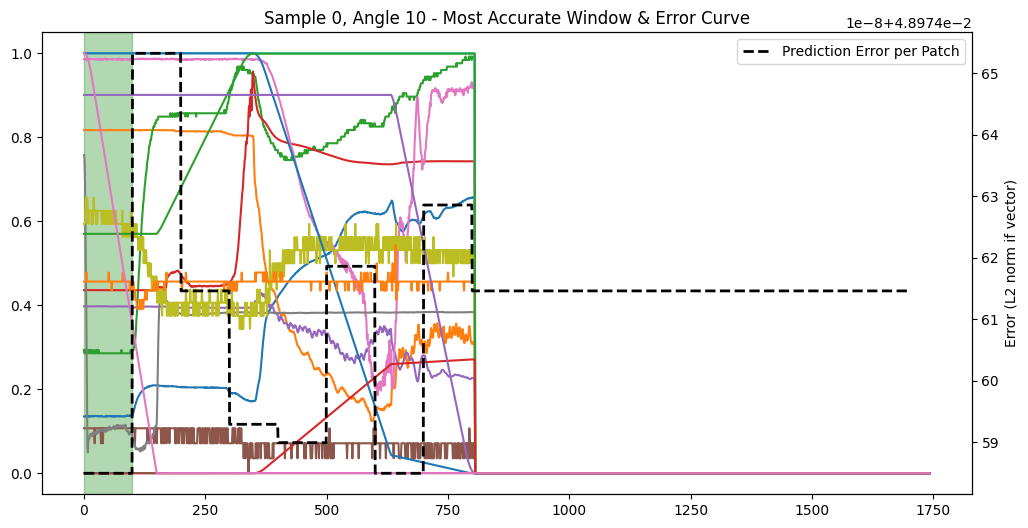

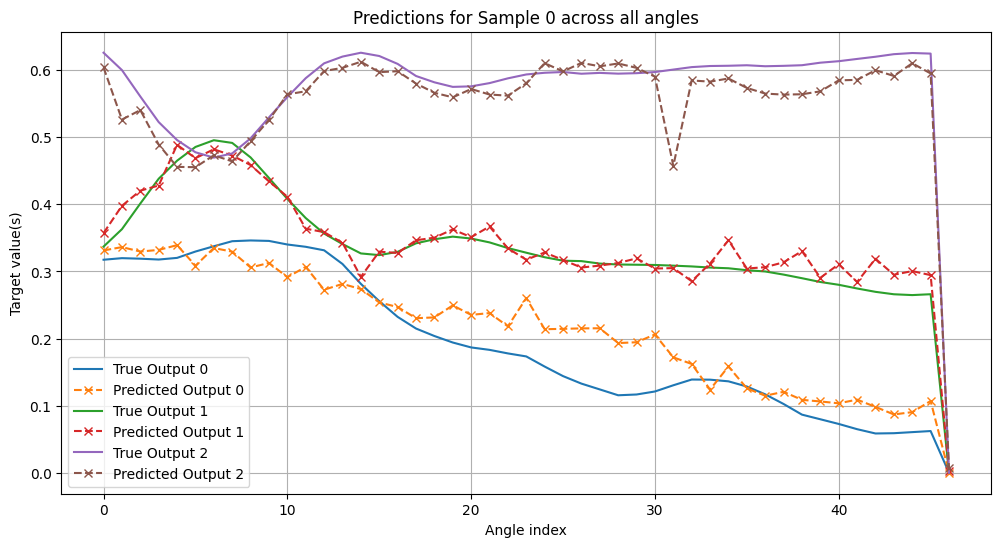

In [ ]:
# Parameters
sample_idx = 0
angle_idx = 10
num_angles = Y.shape[1]      # 47
num_features = X.shape[2]    # number of input features per timestep
patch_size = 100               # you can adjust this based on your sequence length

# Call the function
plot_most_accurate_window_lstm(sample_idx, X, Y, model, num_angles, num_features, patch_size, angle_idx)